In [1]:
from src.utils import get_data_env
from srcv2.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from srcv2.models import PersistenceModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lags            = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lags                = lags,
    nuts_level          = nuts_level,
    log_transform       = True,
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest
    )    

dataorchestrator    = (DataOrchestrator(config).build())

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
# graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('boolean_neighbors_self').construct_dataloaders()
# graphdataloader_gr1 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('gravity1').construct_dataloaders()
# graphdataloader_cm1 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('commuter1').construct_dataloaders()
# graphdataloader_gr2 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('gravity4').construct_dataloaders()
# graphdataloader_cm2 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('commuter4').construct_dataloaders()



==              boolean neighbors               ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.9534, val loss: 0.9699 ✓ (new best)
Epoch 2 train loss: 0.9516, val loss: 0.9706 (patience: 1/20)
Epoch 3 train loss: 0.9509, val loss: 0.9701 (patience: 2/20)
Epoch 4 train loss: 0.9495, val loss: 0.9687 ✓ (new best)
Epoch 5 train loss: 0.9492, val loss: 0.9690 (patience: 1/20)
Epoch 6 train loss: 0.9486, val loss: 0.9692 (patience: 2/20)
Epoch 7 train loss: 0.9485, val loss: 0.9687 (patience: 3/20)
Epoch 8 train loss: 0.9480, val loss: 0.9693 (patience: 4/20)
Epoch 9 train loss: 0.9477, val loss: 0.9688 (patience: 5/20)
Epoch 10 train loss: 0.9468, val loss: 0.9684 ✓ (new best)
Epoch 11 train loss: 0.9464, val loss: 0.9683 ✓ (new best)
Epoch 12 train loss: 0.9469, val loss: 0.9683 (patience: 1/20)
Epoch 13 train loss: 0.9463, val loss: 0.9681 ✓ (new best)
Epoch 14 train loss: 0.9468, val loss: 0.9685 (patience: 

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 524.19it/s]

Test loss: 0.9948


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

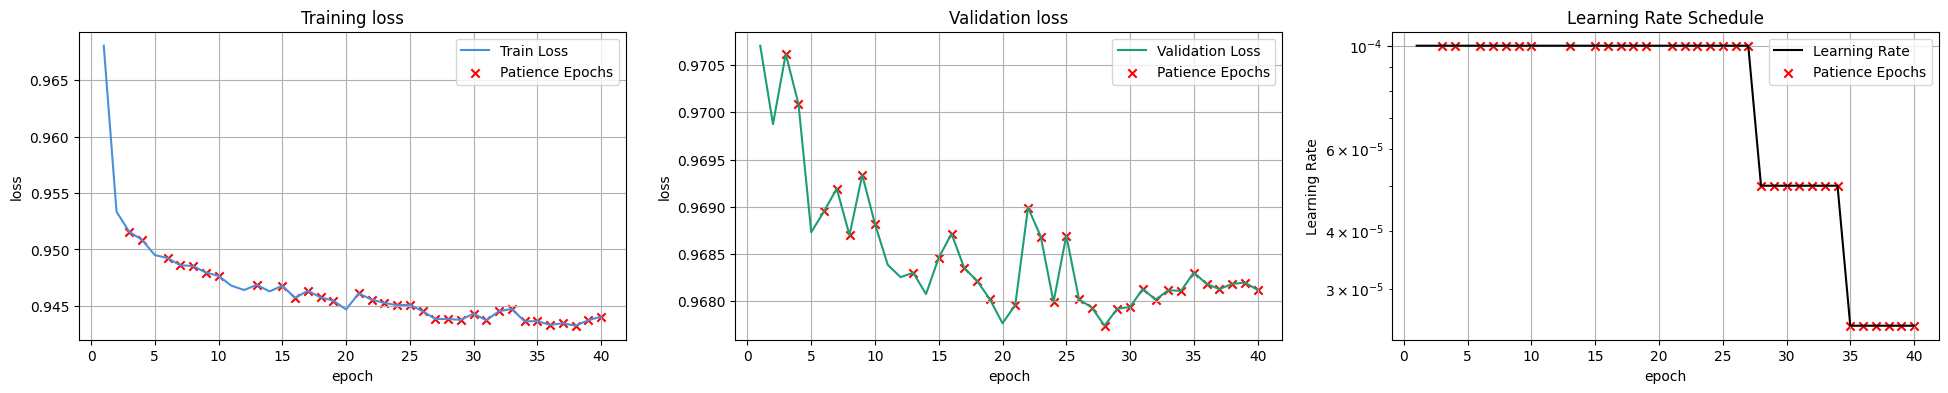

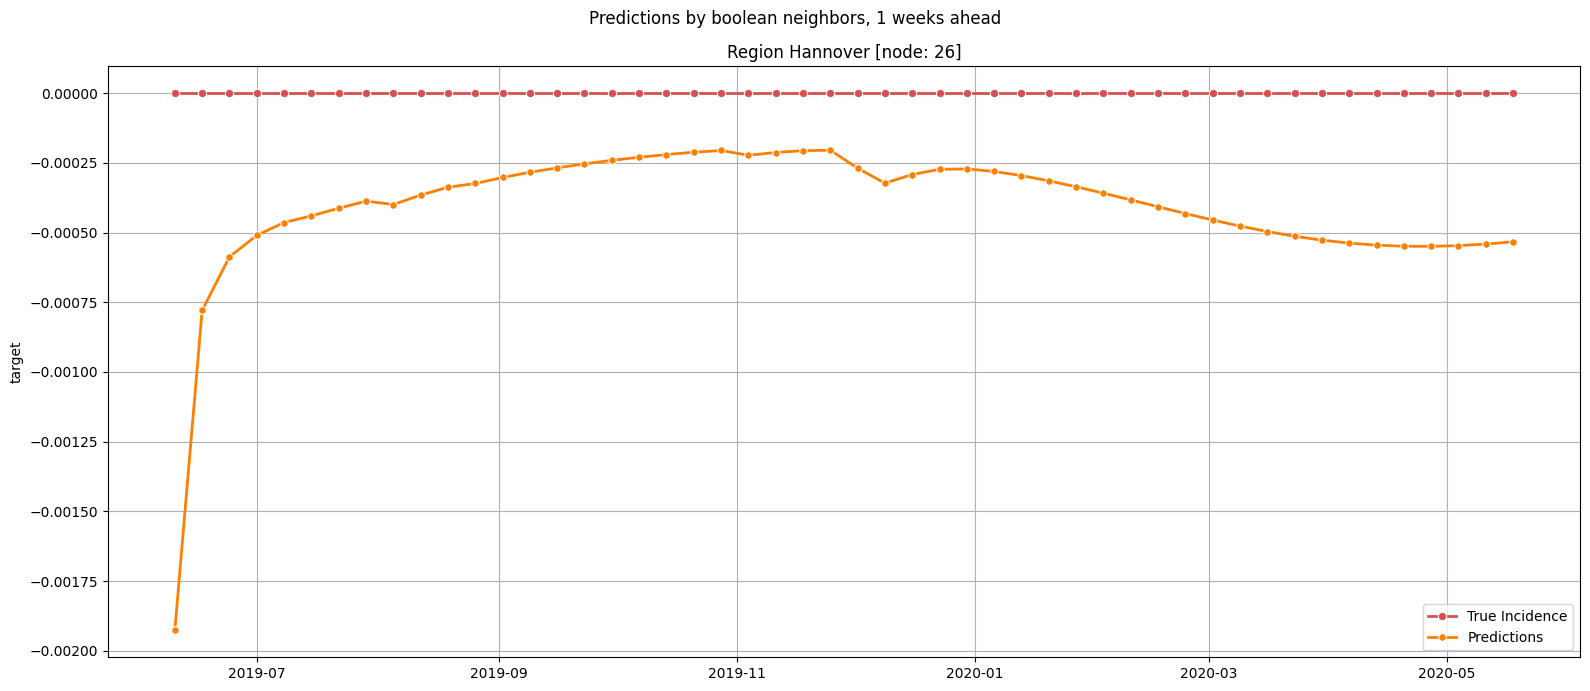

In [3]:
model2 = GATv2Model(graphdataloader_bn, name = 'boolean neighbors')
model2.set_model_hparams()
model2.set_global_hparams(**global_hparams)
model2.train(verbose = 2)
model2.forecast('test')
model2.show_forecasts(26)

In [3]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=100)
rf.train(verbose=2)
rf.forecast('test')

Training loss for horizon 0: RMSE = 0.7055, MAE = 0.4769
Validation loss for horizon 0: RMSE = 0.6348, MAE = 0.4486
Training loss for horizon 1: RMSE = 0.7213, MAE = 0.4863
Validation loss for horizon 1: RMSE = 0.6446, MAE = 0.4571


NodeRFModel(name='NodeRFModel')


==                identity_graph                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.5775, val loss: 0.4093 ✓ (new best)
Epoch 2 train loss: 0.5592, val loss: 0.4066 ✓ (new best)
Epoch 3 train loss: 0.5517, val loss: 0.4043 ✓ (new best)
Epoch 4 train loss: 0.5463, val loss: 0.4029 ✓ (new best)
Epoch 5 train loss: 0.5431, val loss: 0.4011 ✓ (new best)
Epoch 6 train loss: 0.5405, val loss: 0.4002 ✓ (new best)
Epoch 7 train loss: 0.5390, val loss: 0.3993 ✓ (new best)
Epoch 8 train loss: 0.5382, val loss: 0.3980 ✓ (new best)
Epoch 9 train loss: 0.5355, val loss: 0.3972 ✓ (new best)
Epoch 10 train loss: 0.5348, val loss: 0.3957 ✓ (new best)
Epoch 11 train loss: 0.5345, val loss: 0.3950 ✓ (new best)
Epoch 12 train loss: 0.5313, val loss: 0.3942 ✓ (new best)
Epoch 13 train loss: 0.5312, val loss: 0.3938 ✓ (new best)
Epoch 14 train loss: 0.5295, val loss: 0.3928 ✓ (new best)
Epoch 15 train loss: 0.5283, val

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 563.89it/s]

Test loss: 0.3712



==              boolean neighbors               ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.6135, val loss: 0.4301 ✓ (new best)
Epoch 2 train loss: 0.5806, val loss: 0.4258 ✓ (new best)
Epoch 3 train loss: 0.5647, val loss: 0.4262 (patience: 1/20)
Epoch 4 train loss: 0.5573, val loss: 0.4240 ✓ (new best)
Epoch 5 train loss: 0.5538, val loss: 0.4218 ✓ (new best)
Epoch 6 train loss: 0.5517, val loss: 0.4223 (patience: 1/20)
Epoch 7 train loss: 0.5470, val loss: 0.4213 ✓ (new best)
Epoch 8 train loss: 0.5451, val loss: 0.4203 ✓ (new best)
Epoch 9 train loss: 0.5440, val loss: 0.4184 ✓ (new best)
Epoch 10 train loss: 0.5427, val loss: 0.4168 ✓ (new best)
Epoch 11 train loss: 0.5408, val loss: 0.4175 (patience: 1/20)
Epoch 12 train loss: 0.5387, val loss: 0.4157 ✓ (new best)
Epoch 13 train loss: 0.5383, val loss: 0.4148 ✓ (new best)
Epoch 14 train loss: 0.5366, val loss: 0.4139 ✓ (new best)
Epoch 15 train los

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 565.65it/s]

...

Test loss: 0.3533



==                  commuter 3                  ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2285), edge_weight=(2285,))
Epoch 1 train loss: 0.6065, val loss: 0.4444 ✓ (new best)
Epoch 2 train loss: 0.5765, val loss: 0.4349 ✓ (new best)
Epoch 3 train loss: 0.5653, val loss: 0.4291 ✓ (new best)
Epoch 4 train loss: 0.5595, val loss: 0.4268 ✓ (new best)
Epoch 5 train loss: 0.5559, val loss: 0.4249 ✓ (new best)
Epoch 6 train loss: 0.5513, val loss: 0.4230 ✓ (new best)
Epoch 7 train loss: 0.5487, val loss: 0.4215 ✓ (new best)
Epoch 8 train loss: 0.5452, val loss: 0.4205 ✓ (new best)
Epoch 9 train loss: 0.5431, val loss: 0.4190 ✓ (new best)
Epoch 10 train loss: 0.5407, val loss: 0.4154 ✓ (new best)
Epoch 11 train loss: 0.5373, val loss: 0.4135 ✓ (new best)
Epoch 12 train loss: 0.5357, val loss: 0.4122 ✓ (new best)
Epoch 13 train loss: 0.5340, val loss: 0.4113 ✓ (new best)
Epoch 14 train loss: 0.5332, val loss: 0.4096 ✓ (new best)
Epoch 15 train loss: 0.5289, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 487.84it/s]

Test loss: 0.3552


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

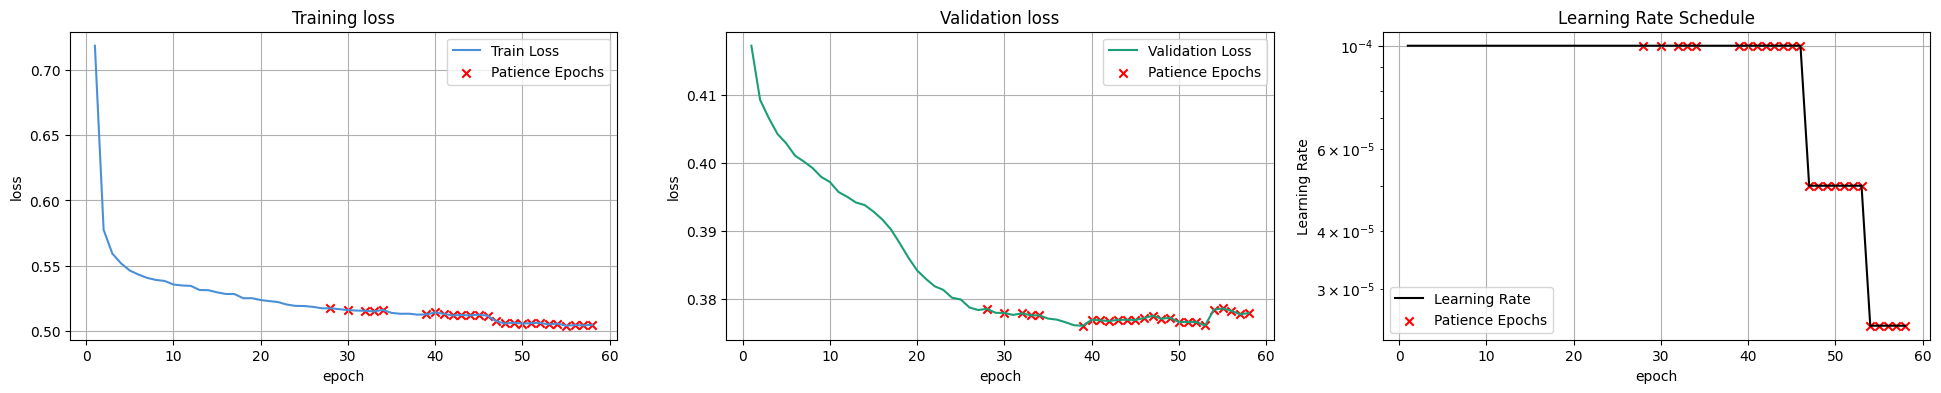

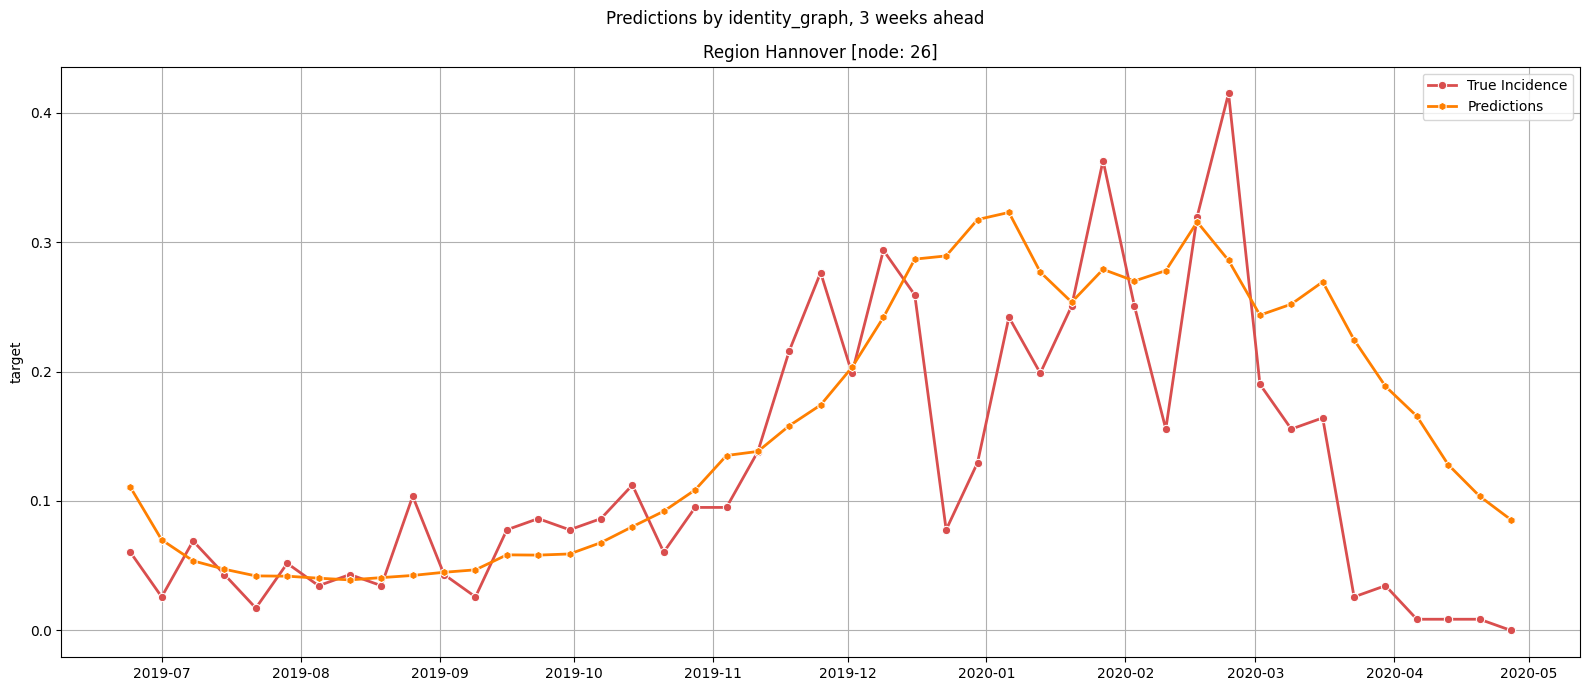

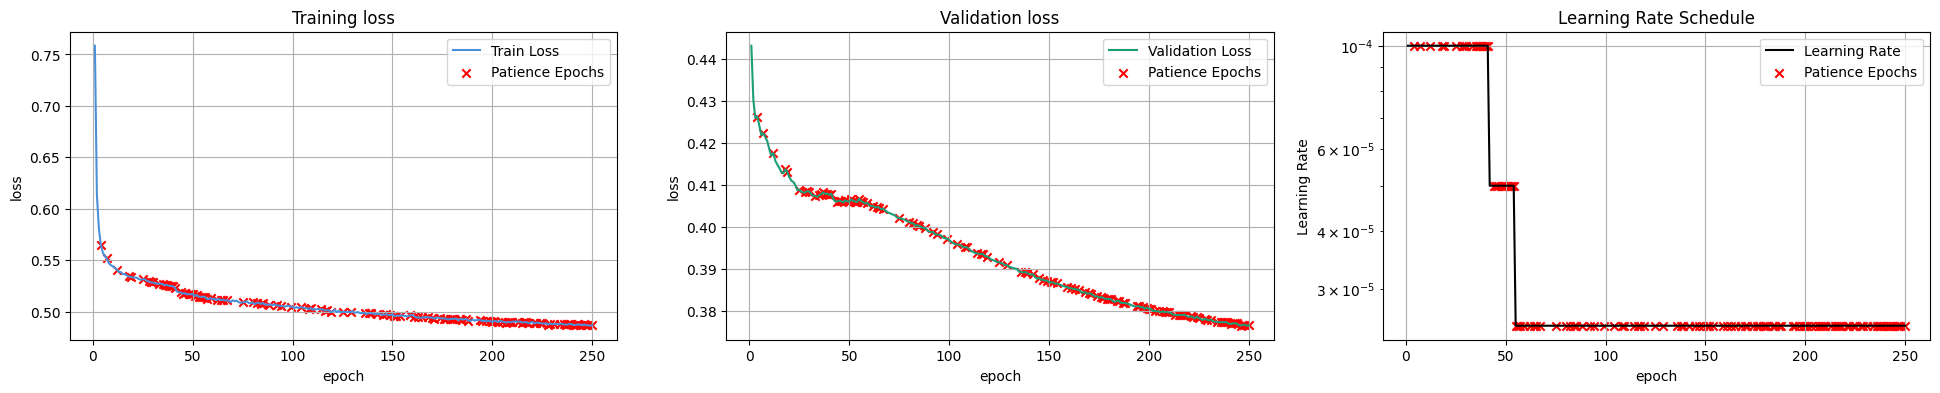

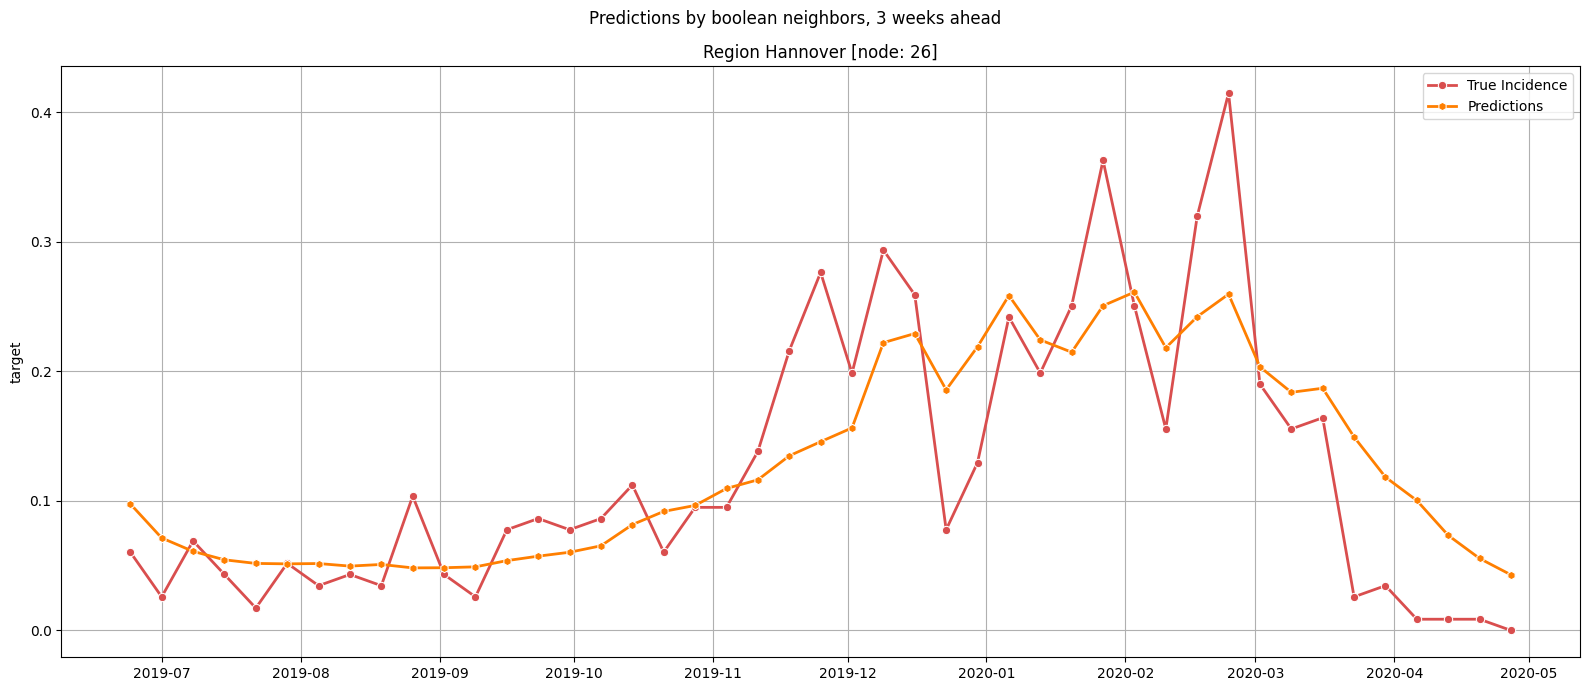

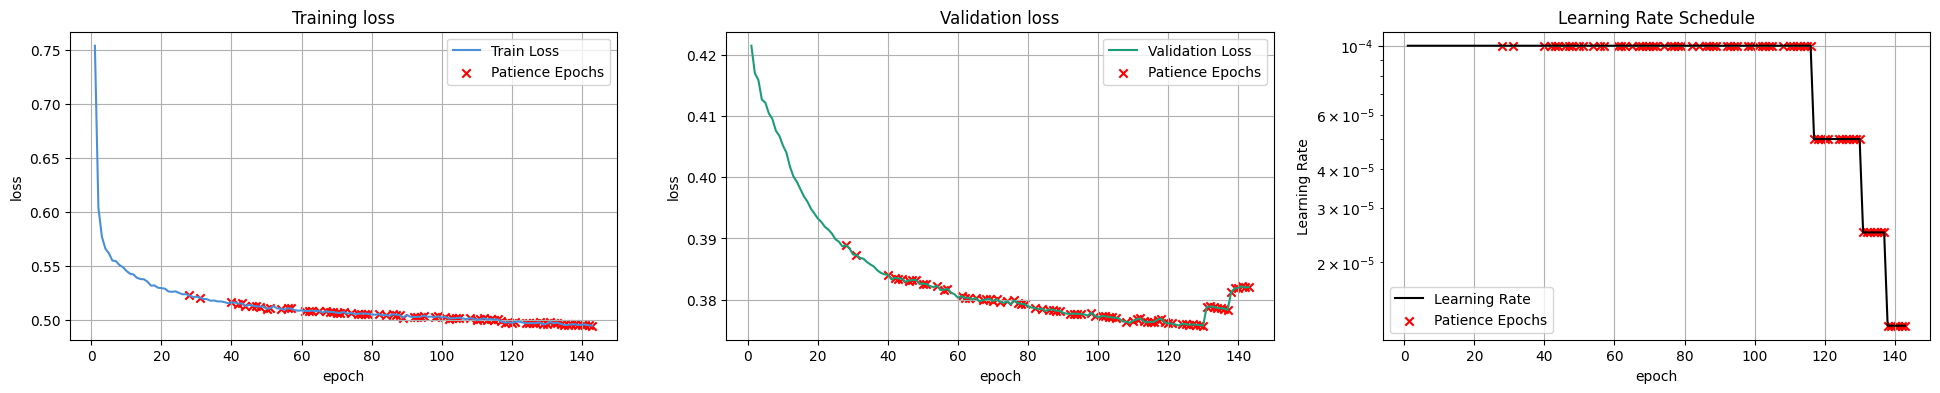

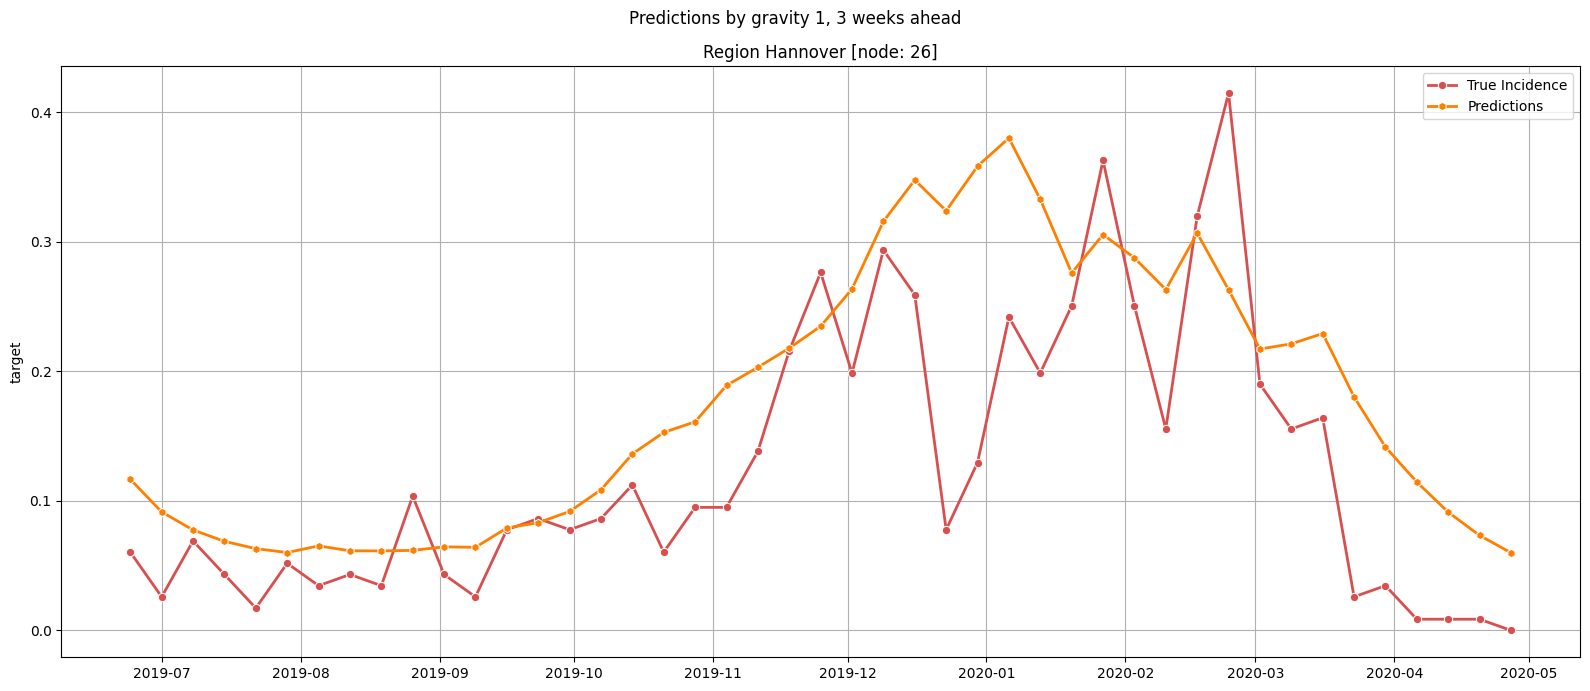

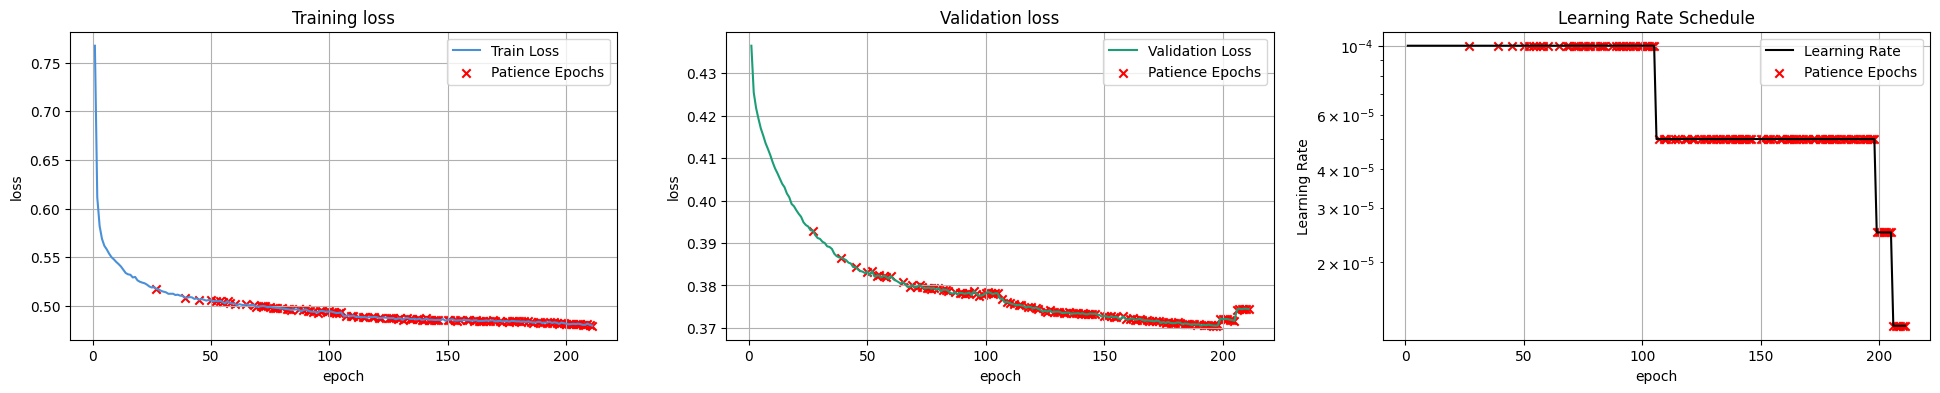

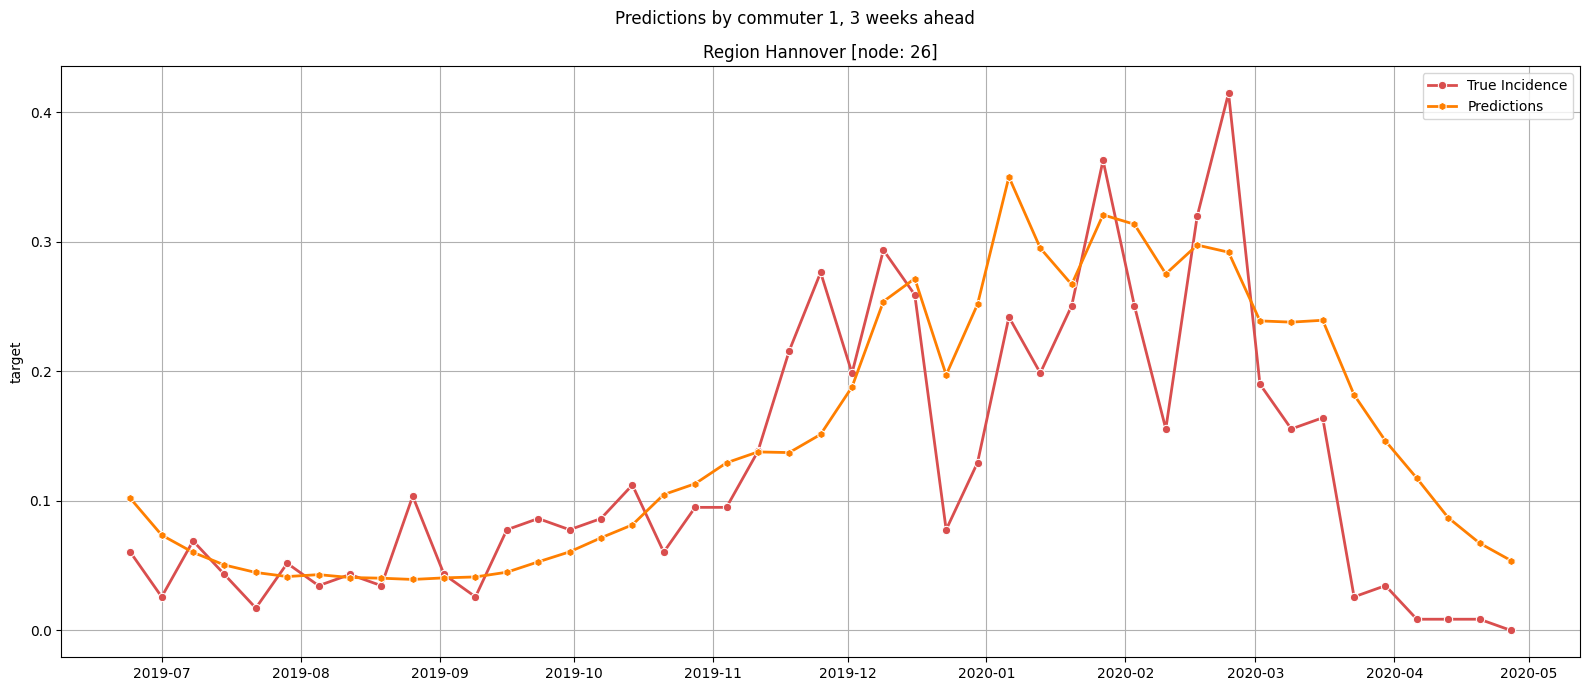

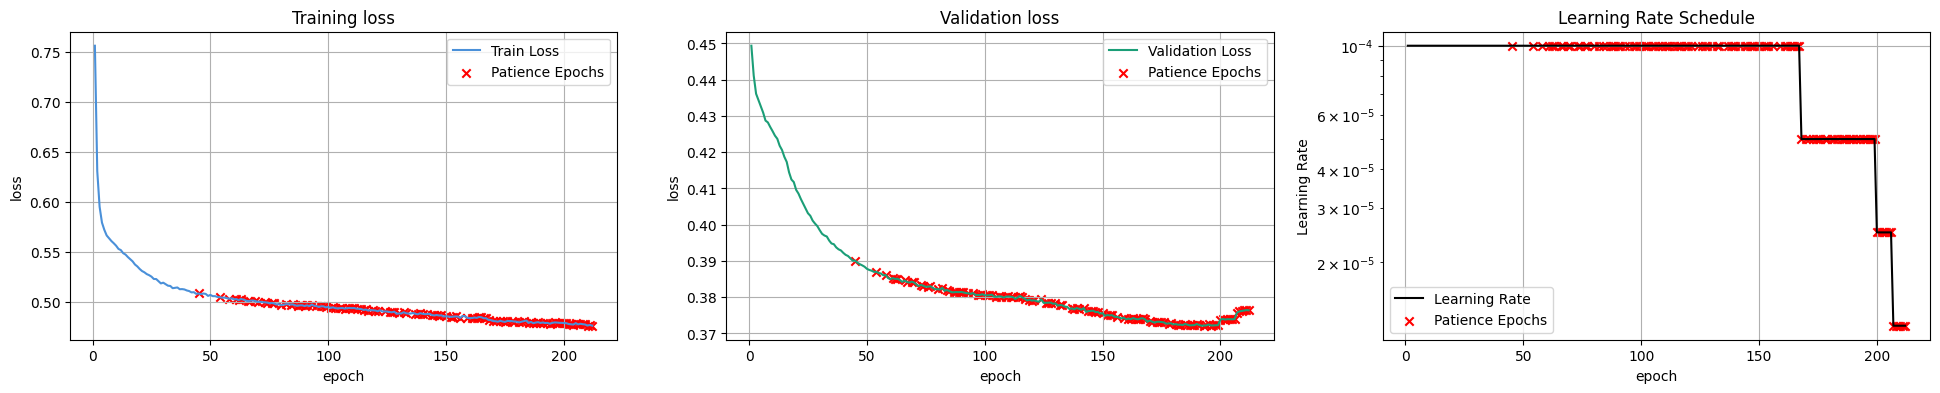

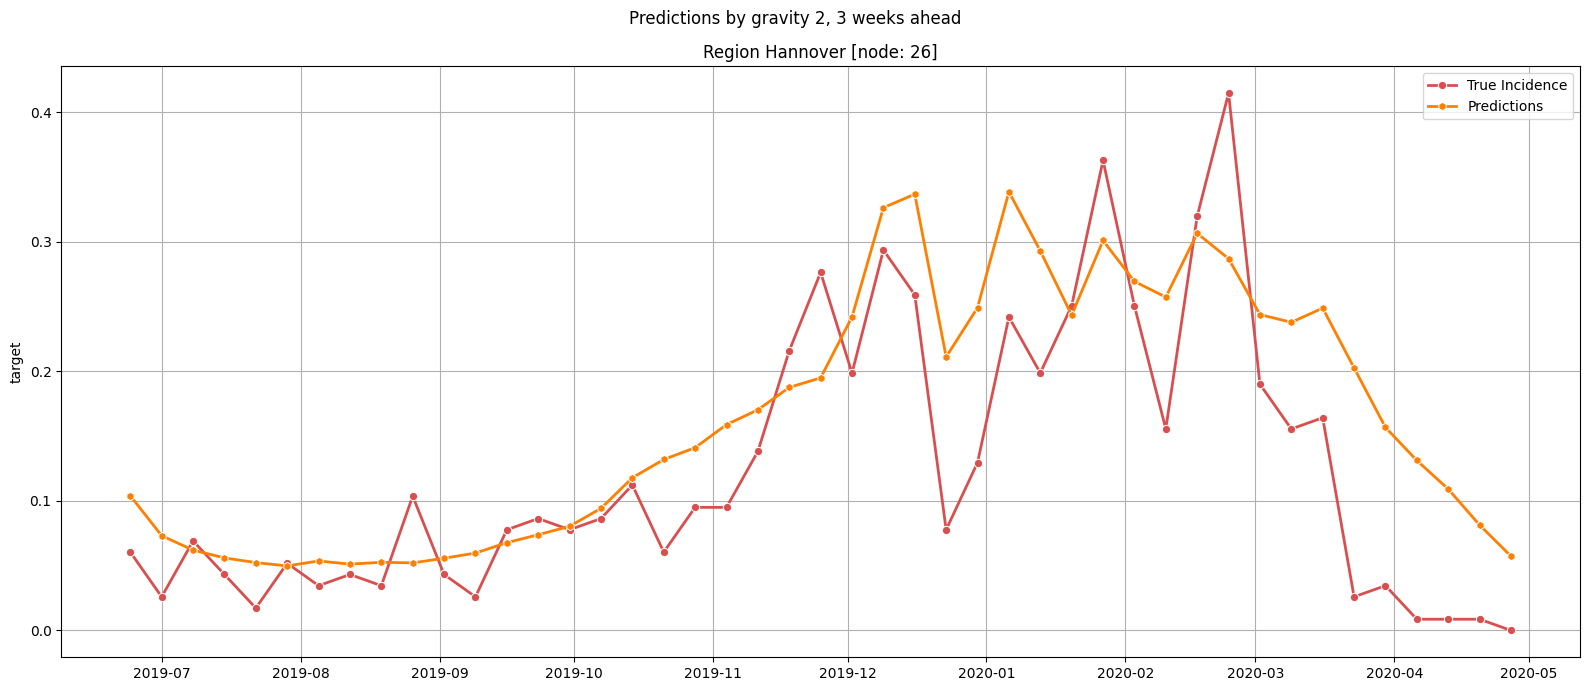

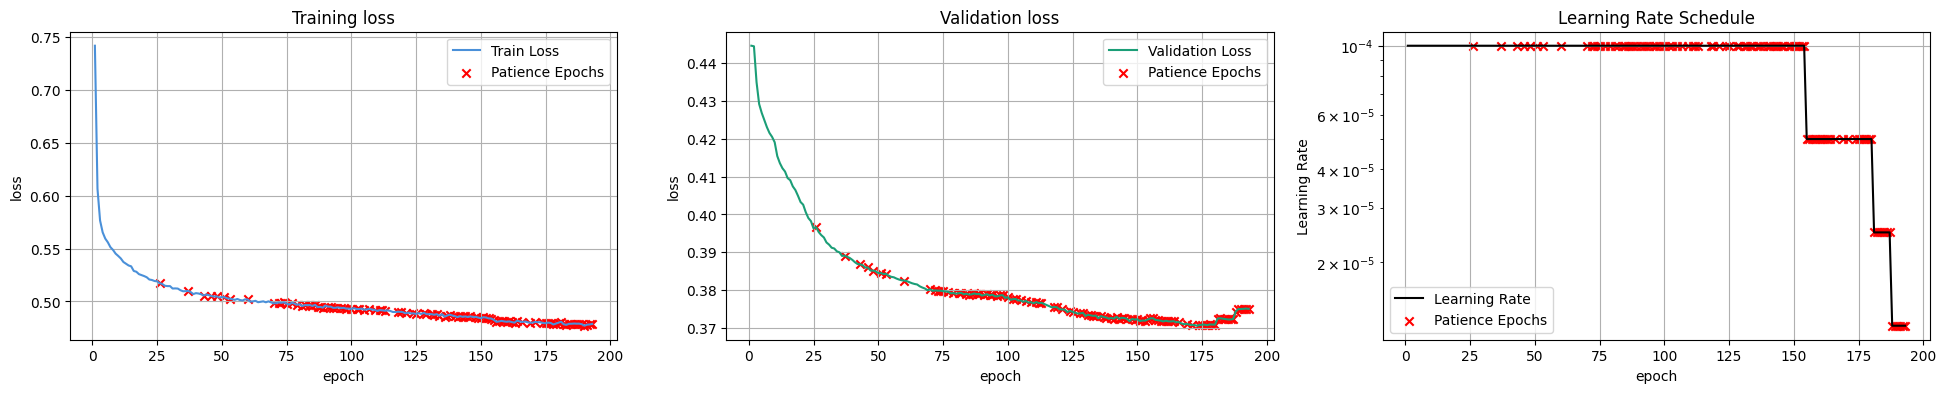

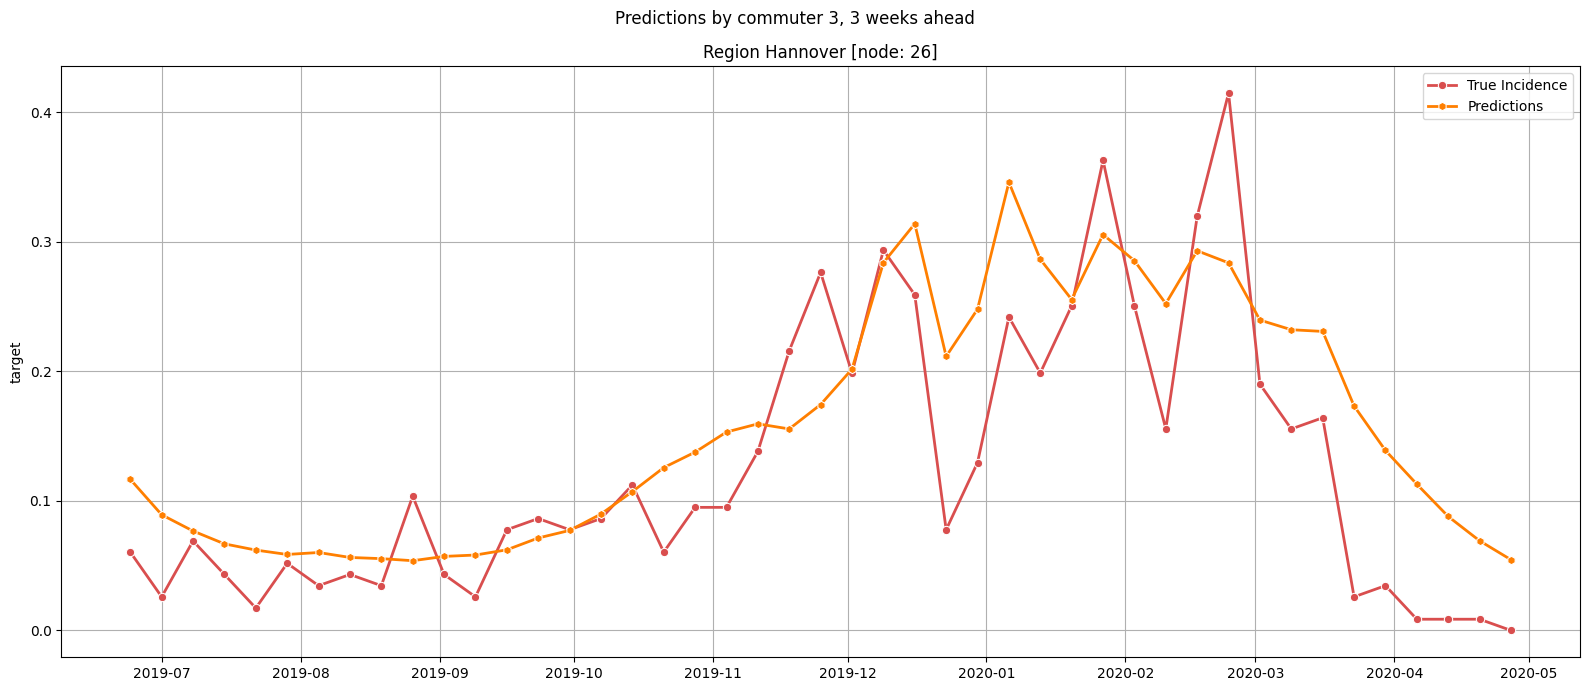

In [4]:
model1 = GATv2Model(graphdataloader_id, name = 'identity_graph')
model1.set_model_hparams()
model1.set_global_hparams(**global_hparams)
model1.train(verbose = 2)
model1.forecast('test')
model1.show_forecasts(26)

model2 = GATv2Model(graphdataloader_bn, name = 'boolean neighbors')
model2.set_model_hparams()
model2.set_global_hparams(**global_hparams)
model2.train(verbose = 2)
model2.forecast('test')
model2.show_forecasts(26)

model3 = GATv2Model(graphdataloader_gr1, name = 'gravity 1')
model3.set_model_hparams()
model3.set_global_hparams(**global_hparams)
model3.train(verbose = 2)
model3.forecast('test')
model3.show_forecasts(26)

model4 = GATv2Model(graphdataloader_cm1, name = 'commuter 1')
model4.set_model_hparams()
model4.set_global_hparams(**global_hparams)
model4.train(verbose = 2)
model4.forecast('test')
model4.show_forecasts(26)

model5 = GATv2Model(graphdataloader_gr2, name = 'gravity 2')
model5.set_model_hparams()
model5.set_global_hparams(**global_hparams)
model5.train(verbose = 2)
model5.forecast('test')
model5.show_forecasts(26)

model6 = GATv2Model(graphdataloader_cm2, name = 'commuter 3')
model6.set_model_hparams()
model6.set_global_hparams(**global_hparams)
model6.train(verbose = 2)
model6.forecast('test')
model6.show_forecasts(26)


==                identity_graph                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.6163, val loss: 0.4297 ✓ (new best)
Epoch 2 train loss: 0.5889, val loss: 0.4293 ✓ (new best)
Epoch 3 train loss: 0.5853, val loss: 0.4288 ✓ (new best)
Epoch 4 train loss: 0.5813, val loss: 0.4285 ✓ (new best)
Epoch 5 train loss: 0.5804, val loss: 0.4281 ✓ (new best)
Epoch 6 train loss: 0.5769, val loss: 0.4277 ✓ (new best)
Epoch 7 train loss: 0.5755, val loss: 0.4275 ✓ (new best)
Epoch 8 train loss: 0.5746, val loss: 0.4273 ✓ (new best)
Epoch 9 train loss: 0.5733, val loss: 0.4271 ✓ (new best)
Epoch 10 train loss: 0.5726, val loss: 0.4270 ✓ (new best)
Epoch 11 train loss: 0.5721, val loss: 0.4267 ✓ (new best)
Epoch 12 train loss: 0.5718, val loss: 0.4266 (patience: 1/20)
Epoch 13 train loss: 0.5707, val loss: 0.4267 (patience: 2/20)
Epoch 14 train loss: 0.5696, val loss: 0.4266 (patience: 3/20)
Epoch 15 train loss:

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 628.21it/s]

Test loss: 0.4211



==              boolean neighbors               ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.6140, val loss: 0.4351 ✓ (new best)
Epoch 2 train loss: 0.5775, val loss: 0.4265 ✓ (new best)
Epoch 3 train loss: 0.5665, val loss: 0.4236 ✓ (new best)
Epoch 4 train loss: 0.5627, val loss: 0.4224 ✓ (new best)
Epoch 5 train loss: 0.5601, val loss: 0.4216 ✓ (new best)
Epoch 6 train loss: 0.5583, val loss: 0.4209 ✓ (new best)
Epoch 7 train loss: 0.5565, val loss: 0.4204 ✓ (new best)
Epoch 8 train loss: 0.5559, val loss: 0.4199 ✓ (new best)
Epoch 9 train loss: 0.5543, val loss: 0.4195 ✓ (new best)
Epoch 10 train loss: 0.5531, val loss: 0.4191 ✓ (new best)
Epoch 11 train loss: 0.5525, val loss: 0.4186 ✓ (new best)
Epoch 12 train loss: 0.5521, val loss: 0.4184 ✓ (new best)
Epoch 13 train loss: 0.5517, val loss: 0.4180 ✓ (new best)
Epoch 14 train loss: 0.5516, val loss: 0.4179 ✓ (new best)
Epoch 15 train loss: 0.5504, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 612.38it/s]

...

Test loss: 0.3949



==                  commuter 3                  ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2285), edge_weight=(2285,))
Epoch 1 train loss: 0.6154, val loss: 0.4304 ✓ (new best)
Epoch 2 train loss: 0.5838, val loss: 0.4293 ✓ (new best)
Epoch 3 train loss: 0.5772, val loss: 0.4287 ✓ (new best)
Epoch 4 train loss: 0.5753, val loss: 0.4279 ✓ (new best)
Epoch 5 train loss: 0.5738, val loss: 0.4274 ✓ (new best)
Epoch 6 train loss: 0.5720, val loss: 0.4266 ✓ (new best)
Epoch 7 train loss: 0.5690, val loss: 0.4261 ✓ (new best)
Epoch 8 train loss: 0.5689, val loss: 0.4257 ✓ (new best)
Epoch 9 train loss: 0.5663, val loss: 0.4253 ✓ (new best)
Epoch 10 train loss: 0.5650, val loss: 0.4248 ✓ (new best)
Epoch 11 train loss: 0.5642, val loss: 0.4244 ✓ (new best)
Epoch 12 train loss: 0.5631, val loss: 0.4239 ✓ (new best)
Epoch 13 train loss: 0.5628, val loss: 0.4237 ✓ (new best)
Epoch 14 train loss: 0.5614, val loss: 0.4232 ✓ (new best)
Epoch 15 train loss: 0.5611, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 630.26it/s]

Test loss: 0.3859


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

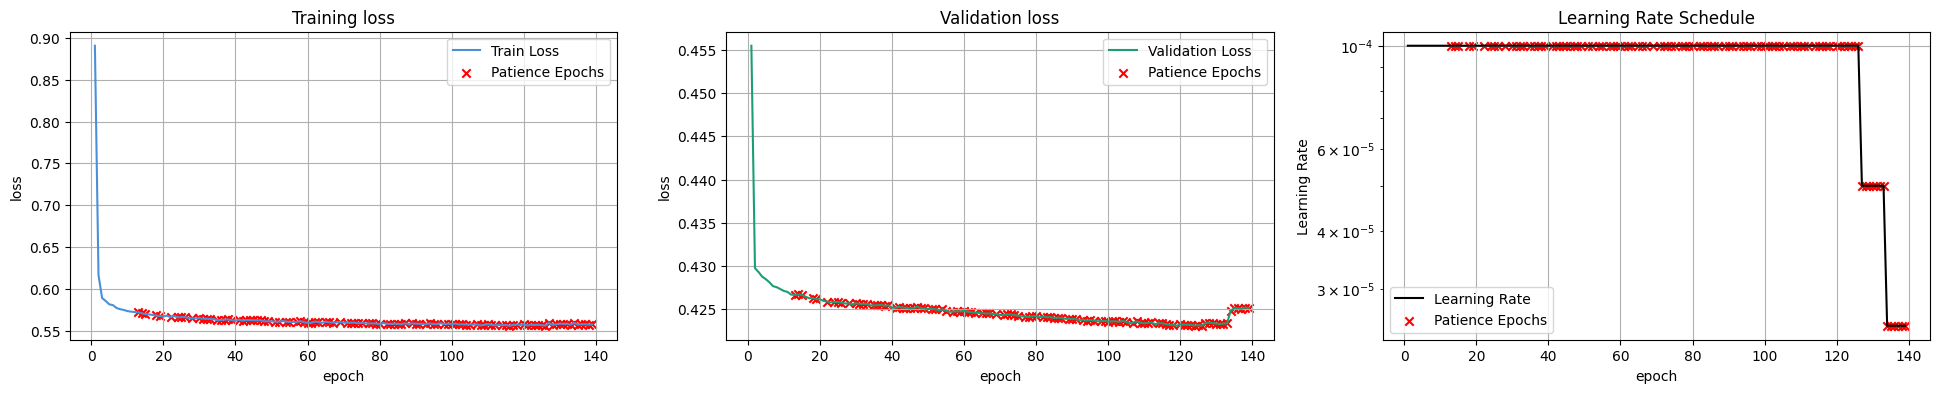

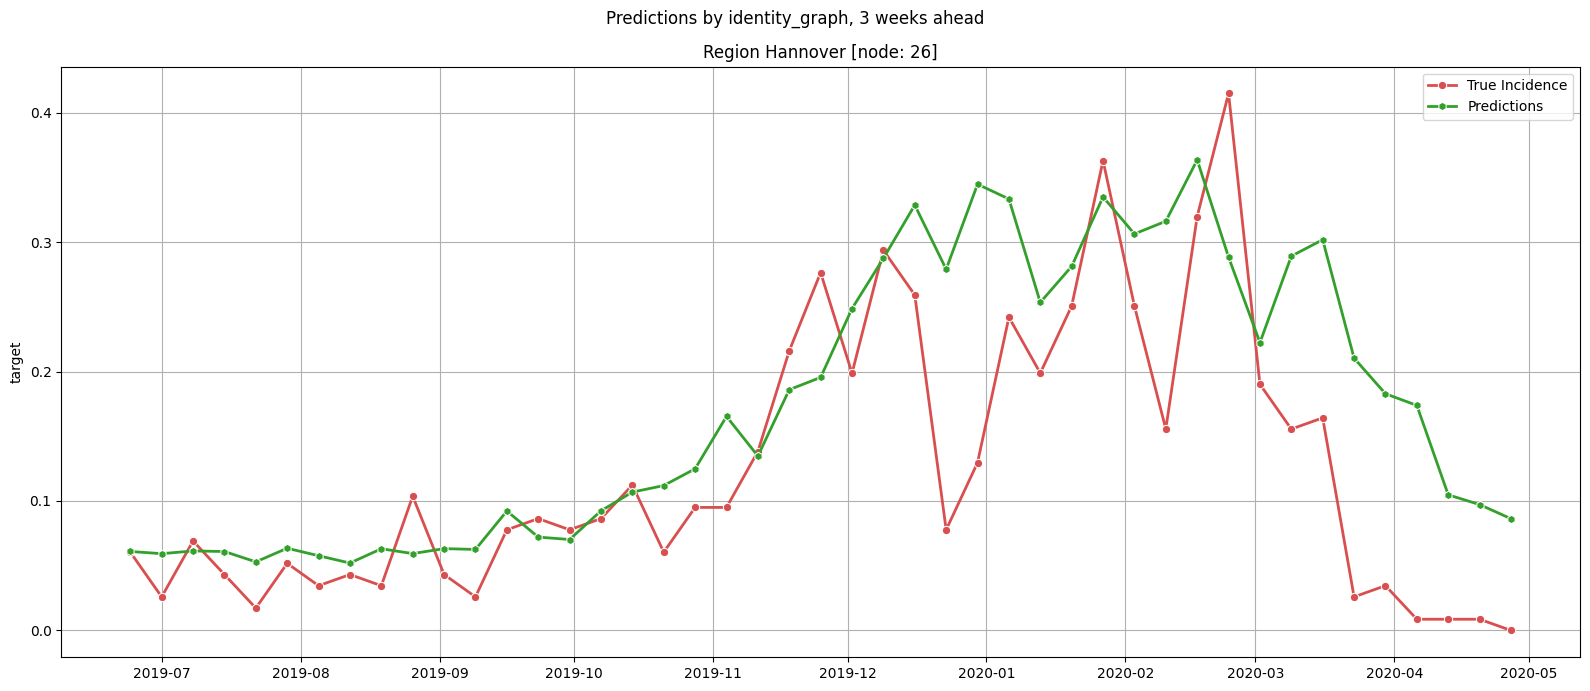

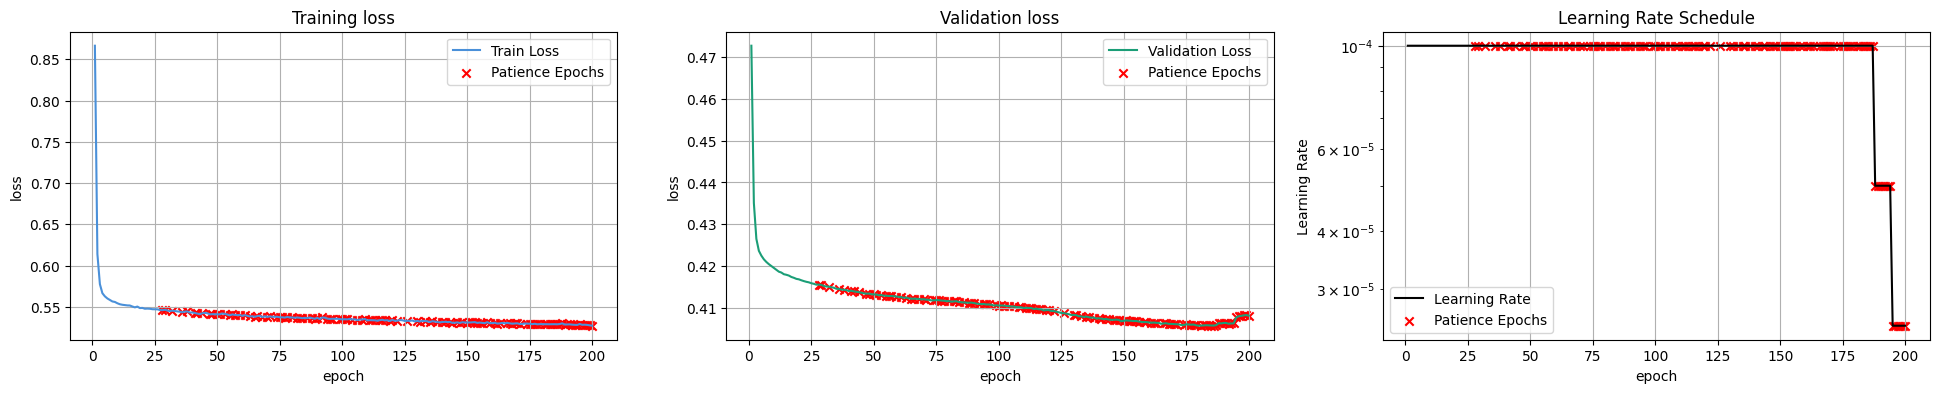

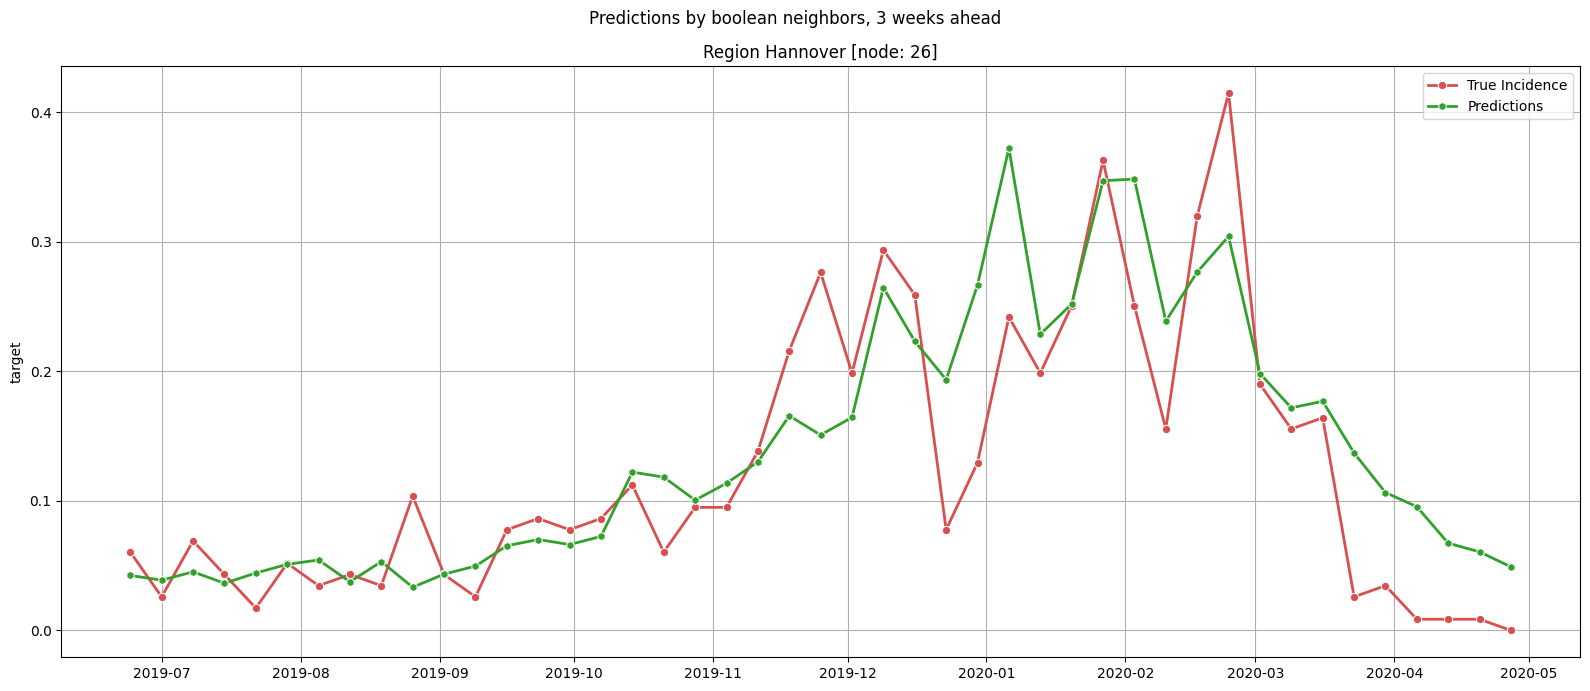

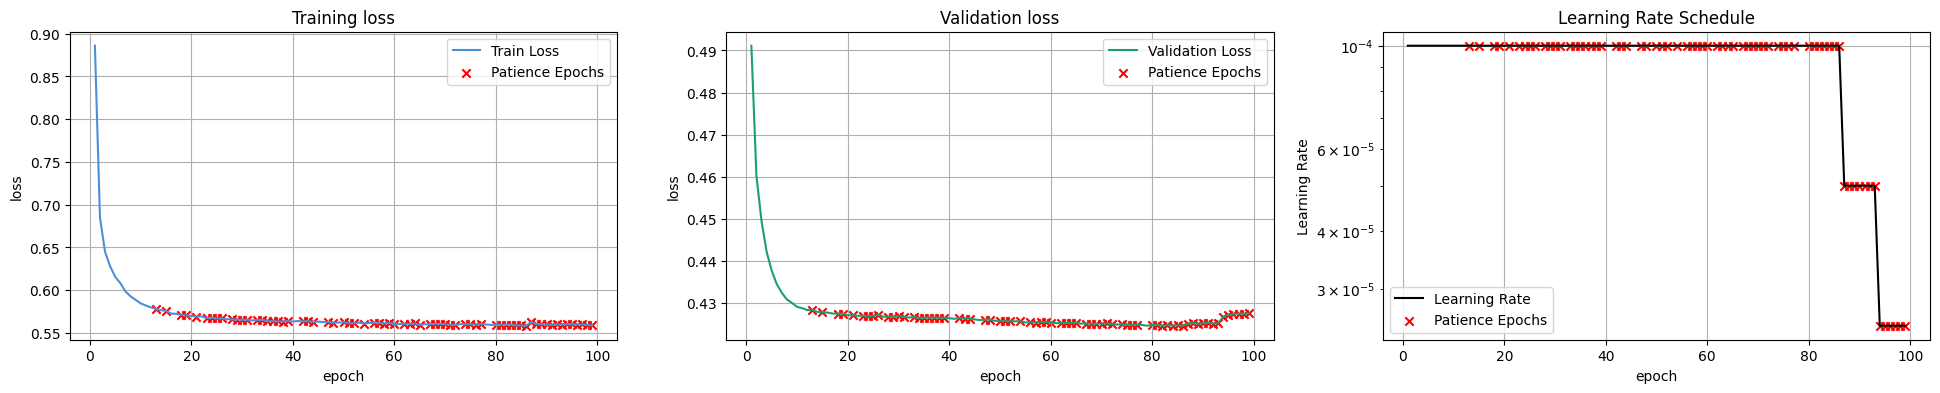

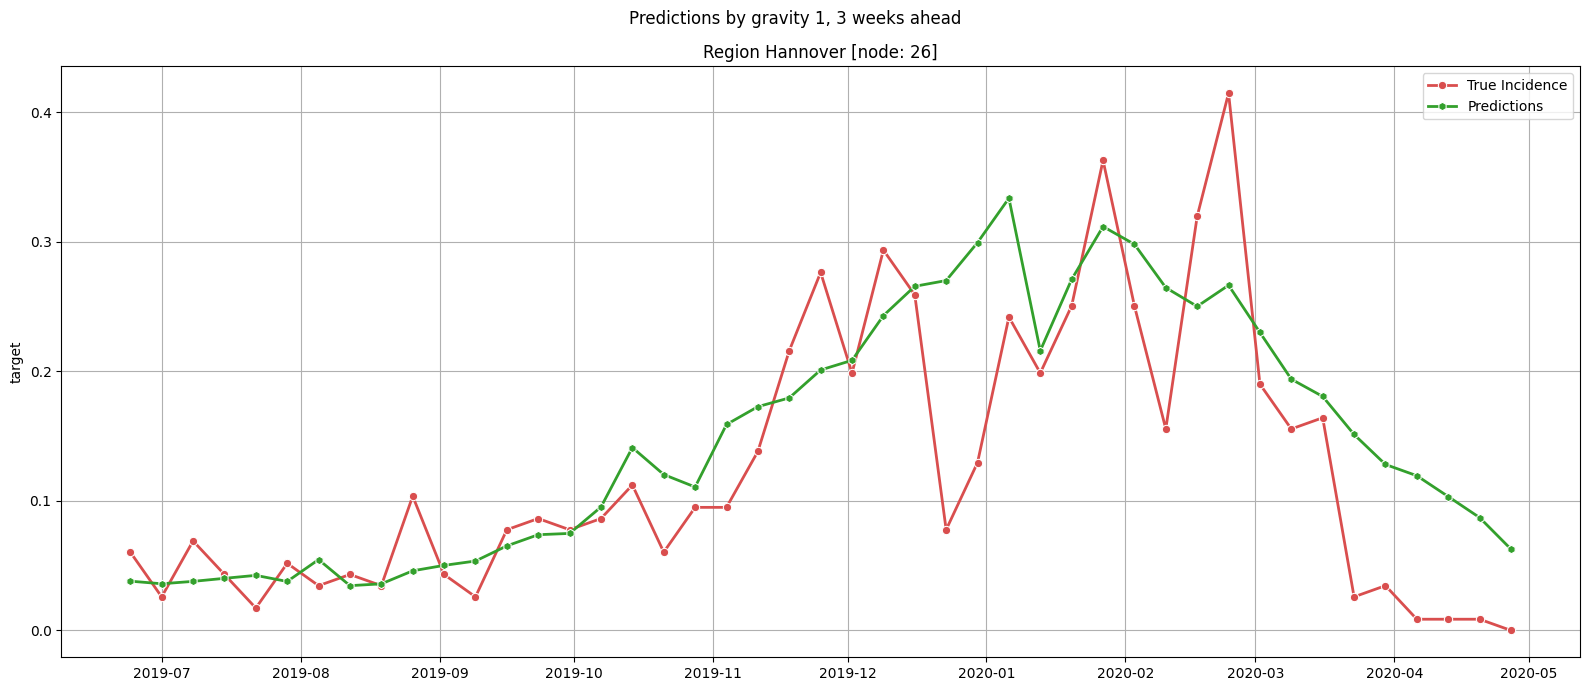

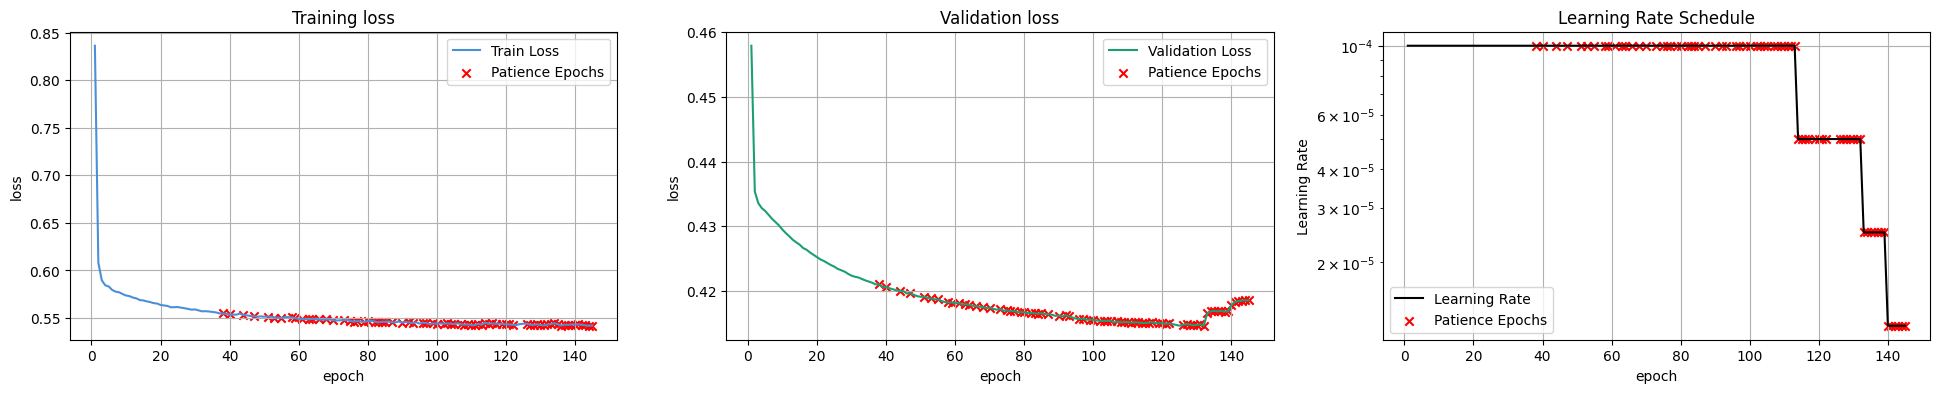

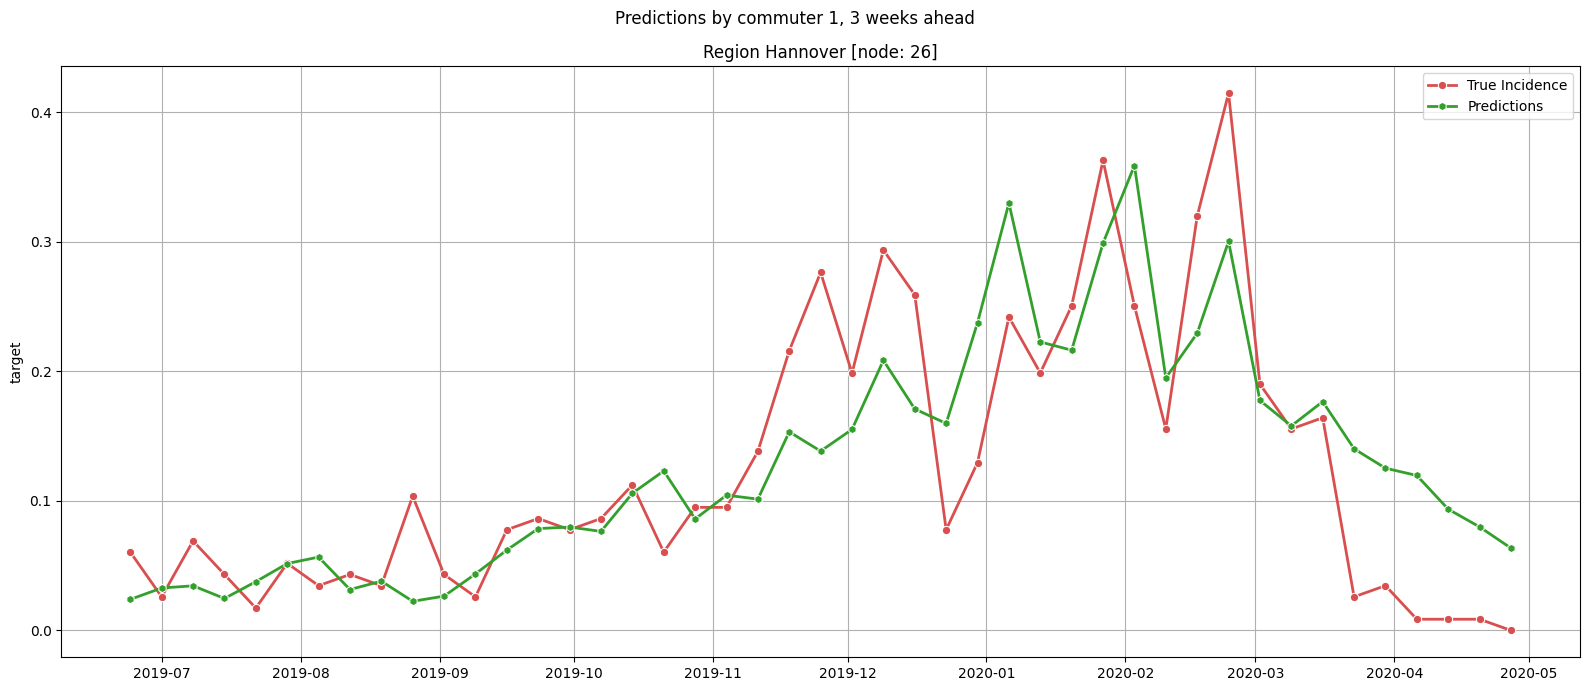

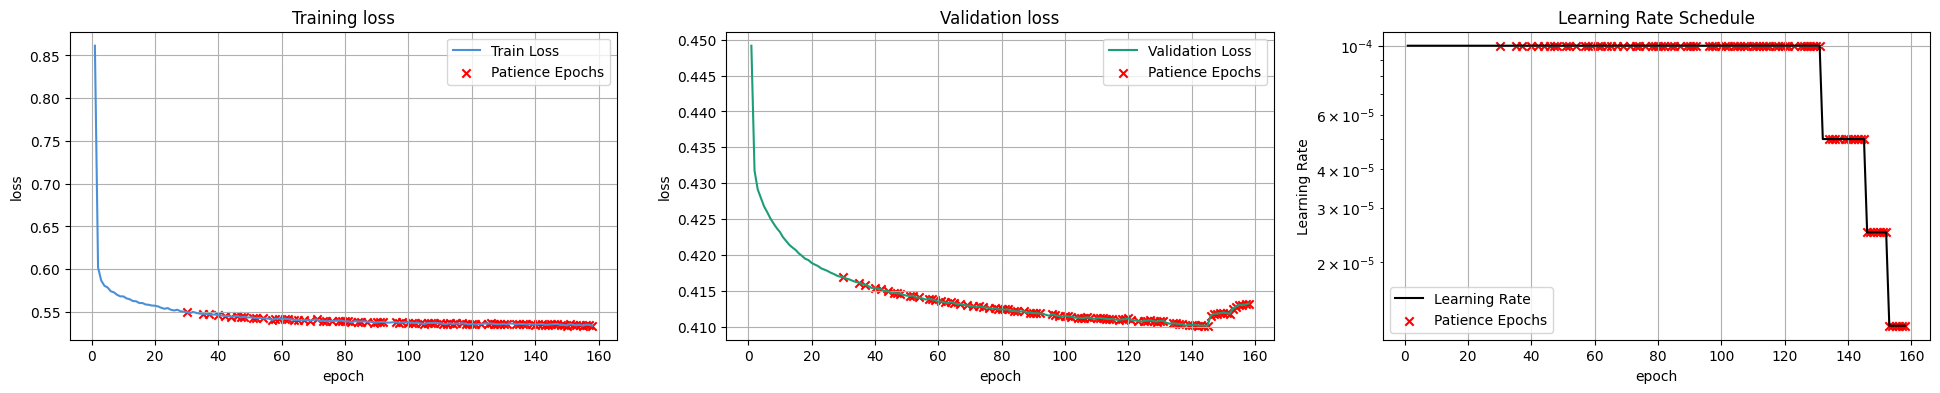

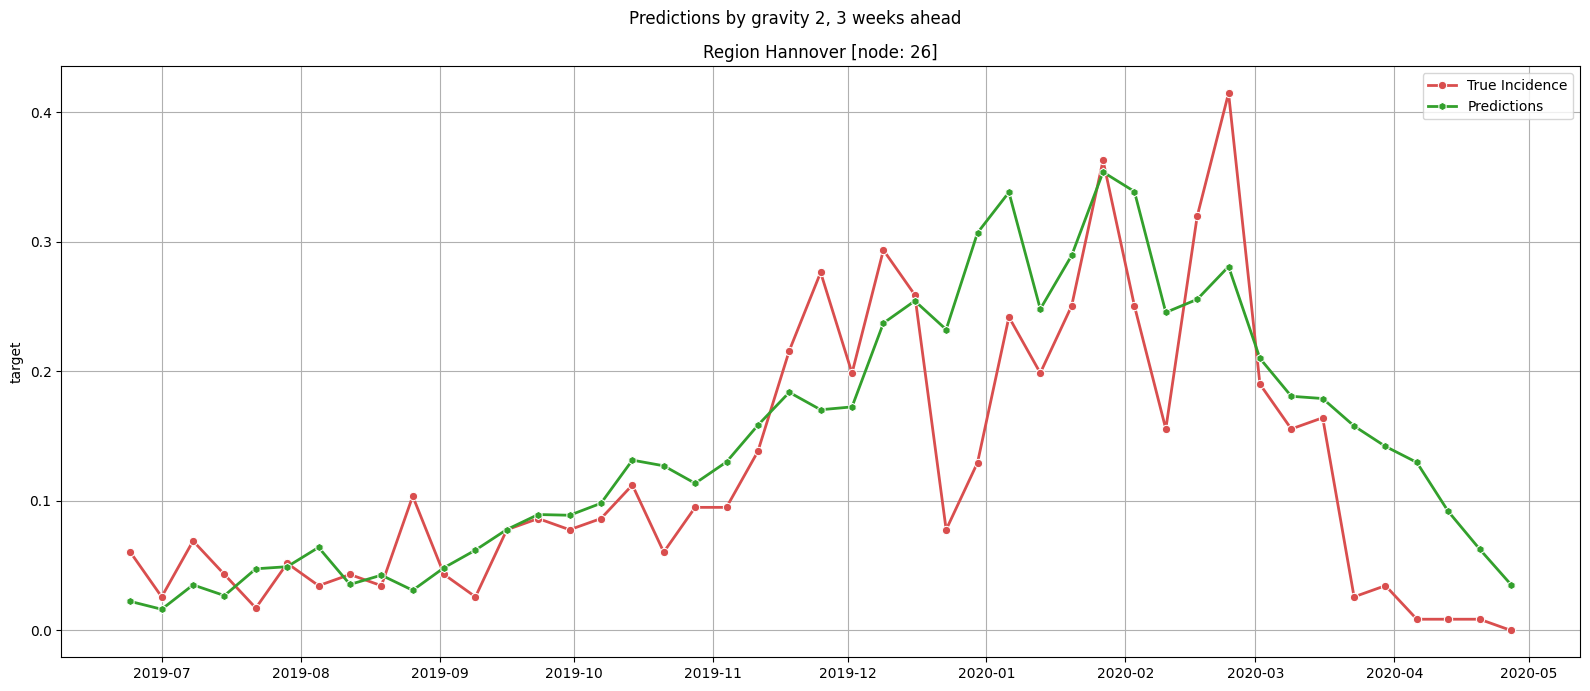

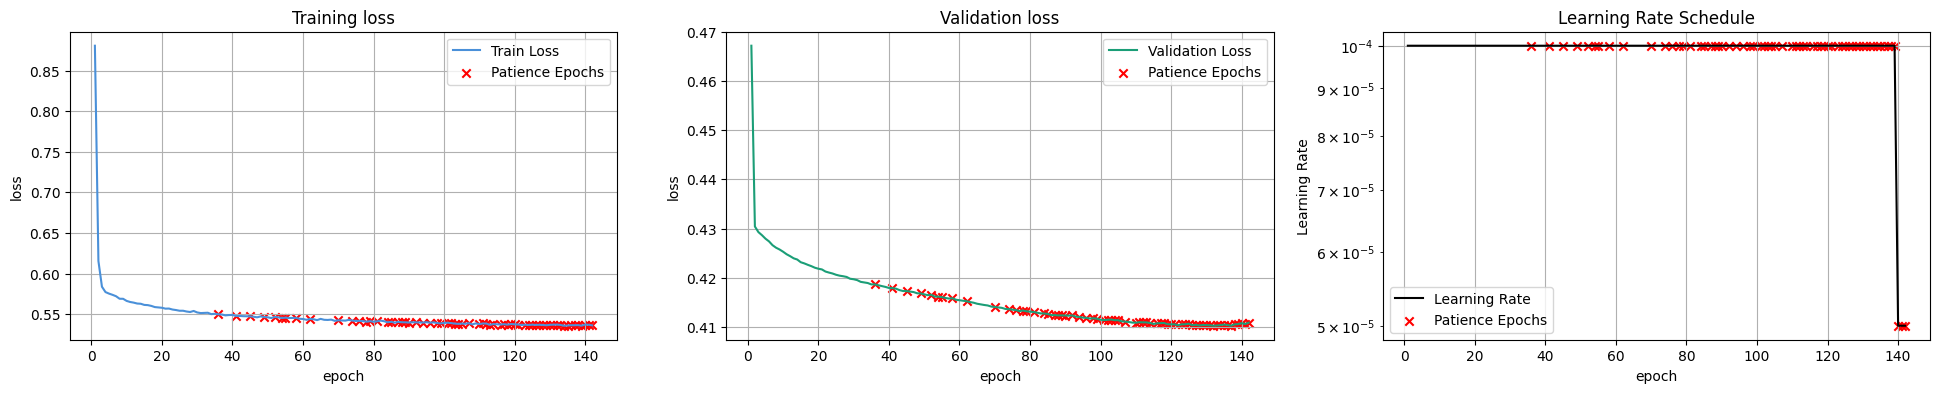

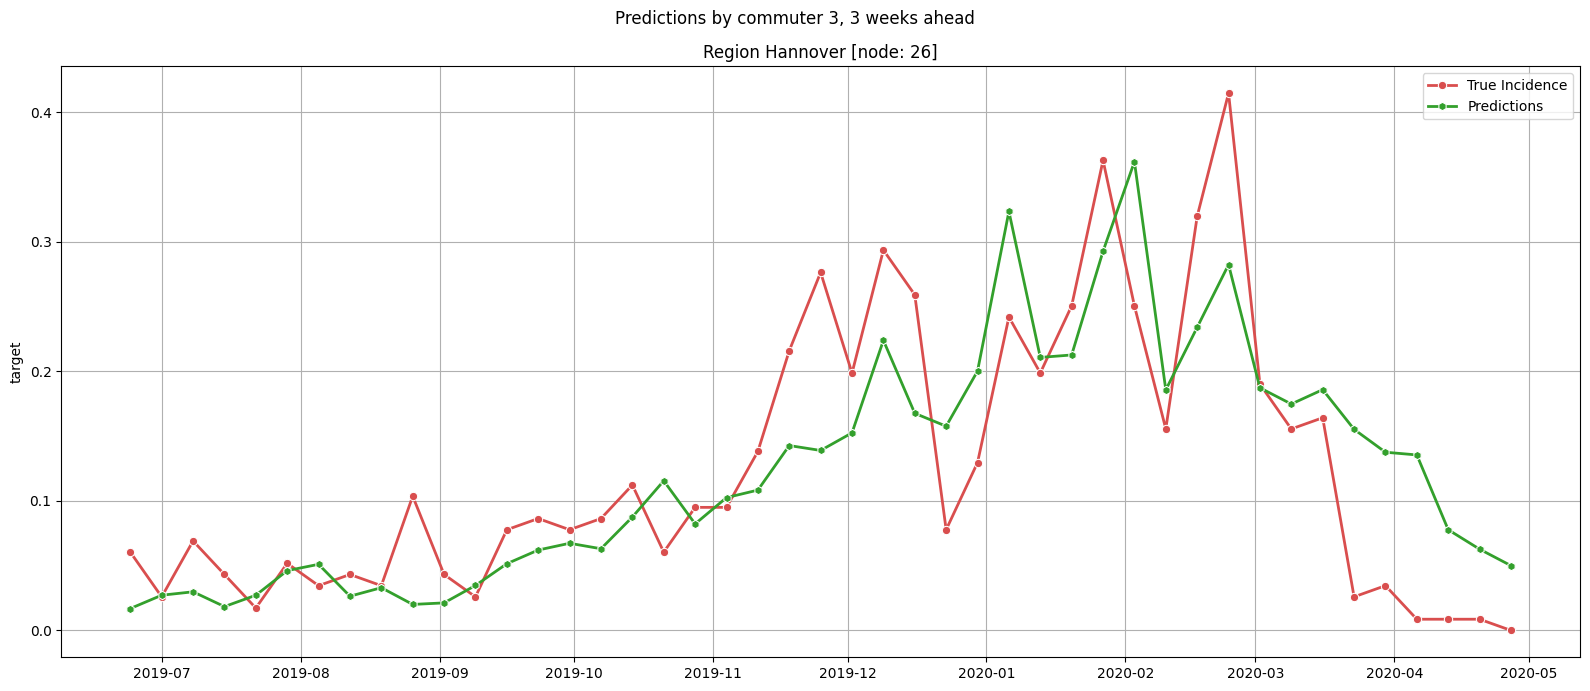

In [8]:
from src.UPDATED_models.deep.spatialgnnmodel import SpatialGNNModel
spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'identity_graph')
spatial_model1.set_model_hparams()
spatial_model1.set_global_hparams(**global_hparams)
spatial_model1.train(verbose = 2)
spatial_model1.forecast('test')
spatial_model1.show_forecasts(26)

spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'boolean neighbors')
spatial_model2.set_model_hparams()
spatial_model2.set_global_hparams(**global_hparams)
spatial_model2.train(verbose = 2)
spatial_model2.forecast('test')
spatial_model2.show_forecasts(26)

spatial_model3 = SpatialGNNModel(graphdataloader_gr1, name = 'gravity 1')
spatial_model3.set_model_hparams()
spatial_model3.set_global_hparams(**global_hparams)
spatial_model3.train(verbose = 2)
spatial_model3.forecast('test')
spatial_model3.show_forecasts(26)

spatial_model4 = SpatialGNNModel(graphdataloader_cm1, name = 'commuter 1')
spatial_model4.set_model_hparams()
spatial_model4.set_global_hparams(**global_hparams)
spatial_model4.train(verbose = 2)
spatial_model4.forecast('test')
spatial_model4.show_forecasts(26)

spatial_model5 = SpatialGNNModel(graphdataloader_gr2, name = 'gravity 2')
spatial_model5.set_model_hparams()
spatial_model5.set_global_hparams(**global_hparams)
spatial_model5.train(verbose = 2)
spatial_model5.forecast('test')
spatial_model5.show_forecasts(26)

spatial_model6 = SpatialGNNModel(graphdataloader_cm2, name = 'commuter 3')
spatial_model6.set_model_hparams()
spatial_model6.set_global_hparams(**global_hparams)
spatial_model6.train(verbose = 2)
spatial_model6.forecast('test')
spatial_model6.show_forecasts(26)

In [ ]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:06<00:00,  1.30s/it]
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

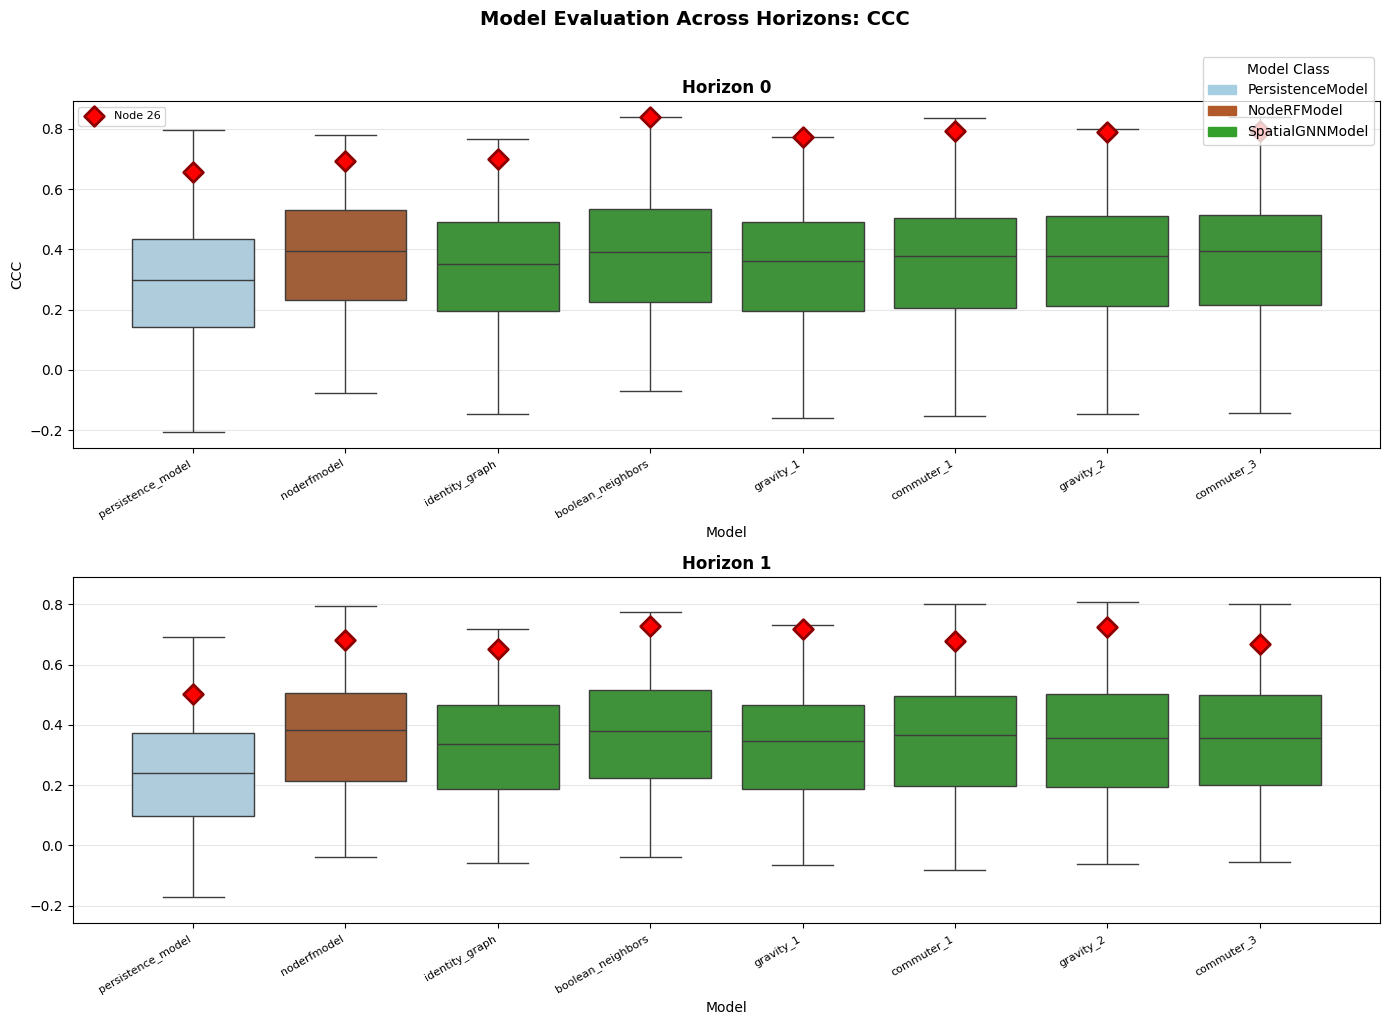

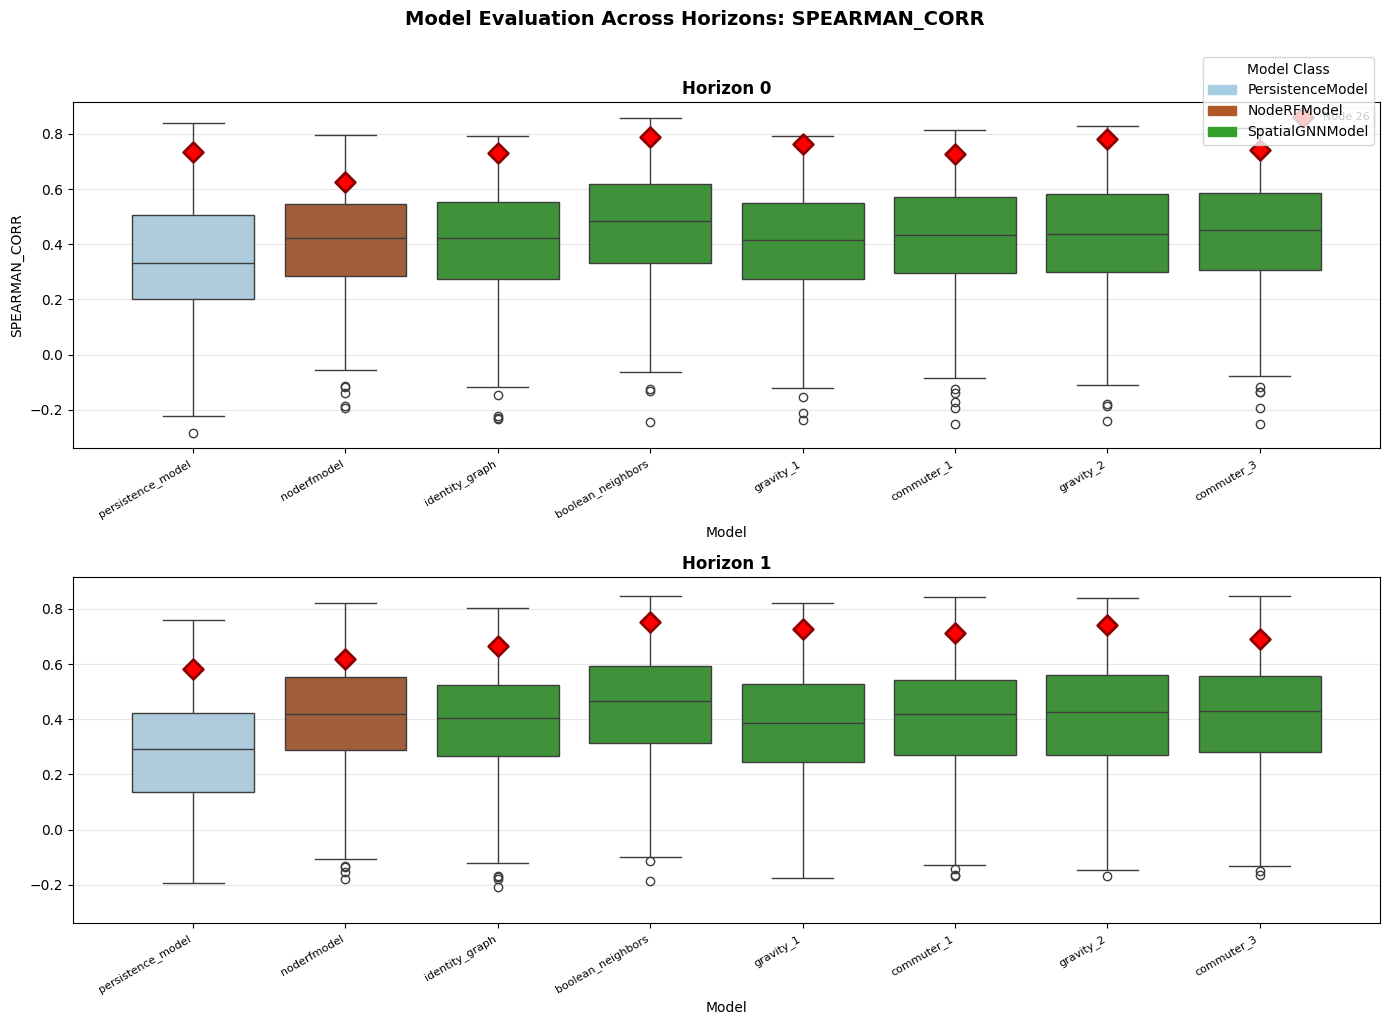

In [9]:
from src.UPDATED_evaluation.evaluator import Evaluator
evaluation_gcn = Evaluator([persistence, rf, spatial_model1, spatial_model2, spatial_model3, spatial_model4, spatial_model5, spatial_model6])
evaluation_gcn.add_evaluation(0, 'test')
evaluation_gcn.add_evaluation(1, 'test')

evaluation_gcn.plotter.plot_metric_horizons_separate('ccc', horizons = [0,1], plot_type='box', highlight_node=26)
evaluation_gcn.plotter.plot_metric_horizons_separate('spearman_corr', horizons = [0,1], plot_type='box', highlight_node=26)

computing metrics:   0%|                                                                                                                                                                | 0/5 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:06<00:00,  1.32s/it]
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

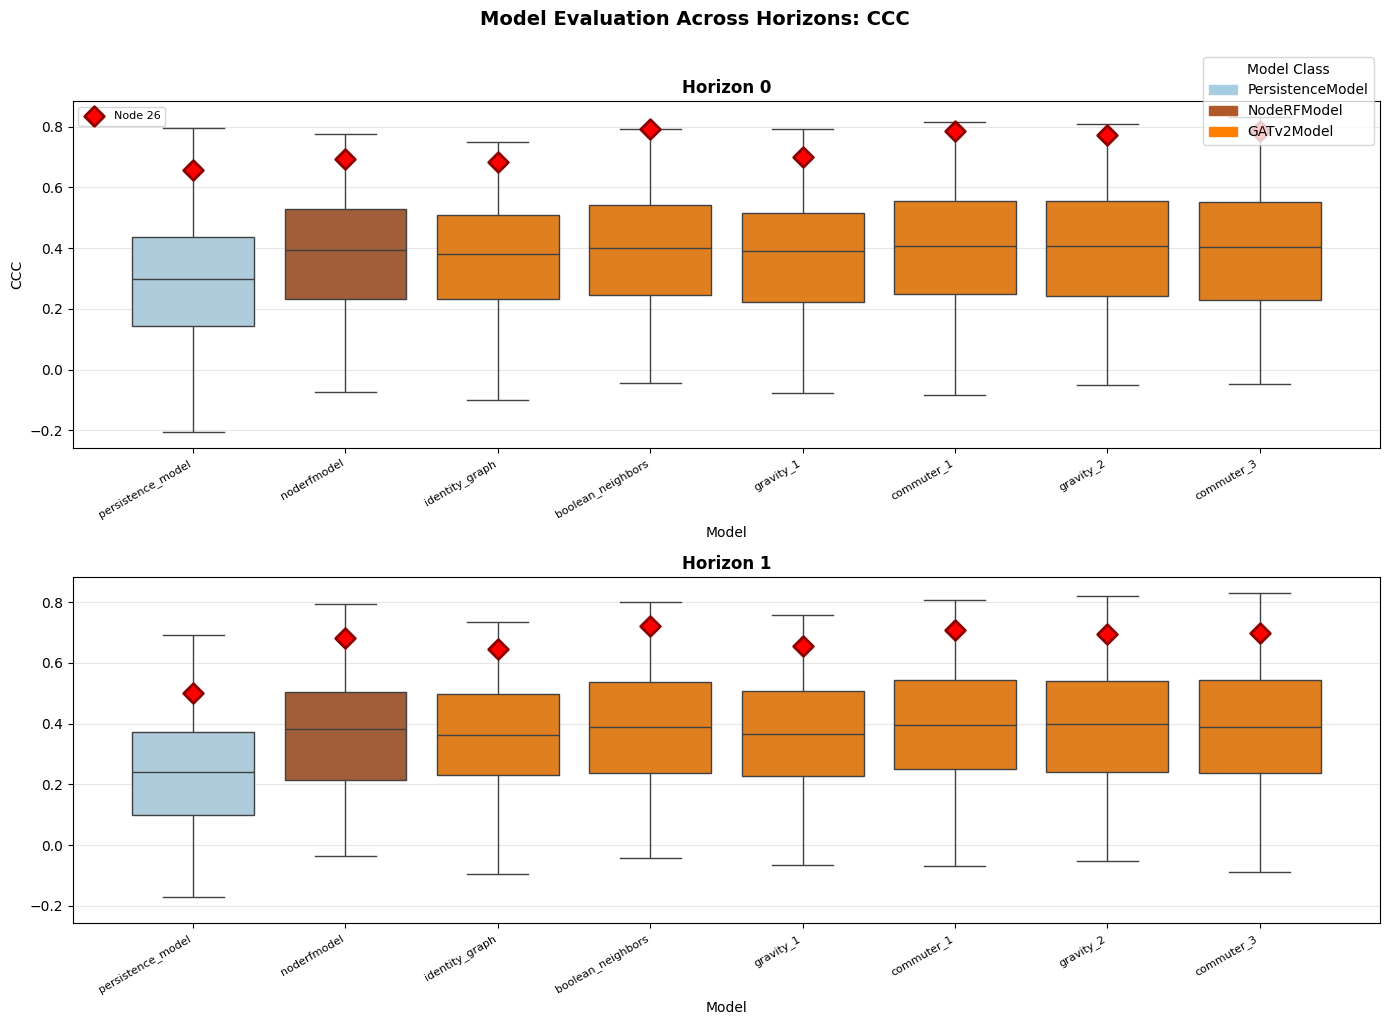

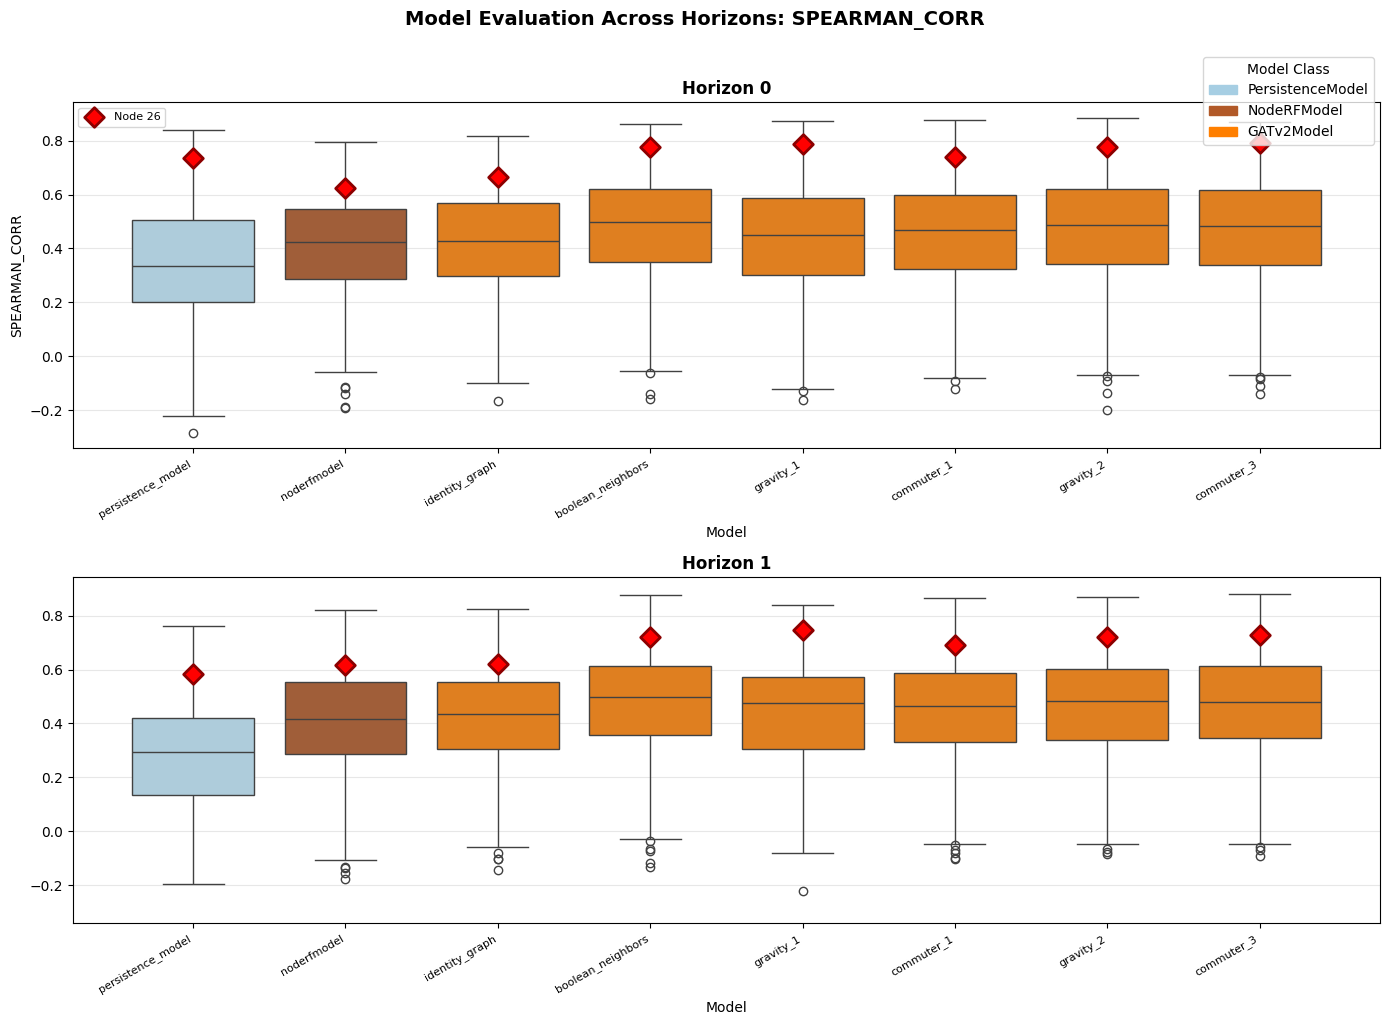

In [7]:
from src.UPDATED_evaluation.evaluator import Evaluator
evaluation_gatv2 = Evaluator([persistence, rf, model1, model2, model3, model4, model5, model6])
evaluation_gatv2.add_evaluation(0, 'test')
evaluation_gatv2.add_evaluation(1, 'test')

evaluation_gatv2.plotter.plot_metric_horizons_separate('ccc', horizons = [0,1], plot_type='box', highlight_node=26)
evaluation_gatv2.plotter.plot_metric_horizons_separate('spearman_corr', horizons = [0,1], plot_type='box', highlight_node=26)